# t-SNE: t-Distributed Stochastic Neighbor Embedding

## Overview
t-SNE is a powerful **non-linear dimensionality reduction** technique that excels at visualizing high-dimensional data in 2D or 3D. Unlike linear methods (PCA), t-SNE preserves local neighborhood structure, making it ideal for visualization and pattern discovery.

## Key Concept: Preserving Local Structure

**Problem with PCA and other linear methods:**
- They preserve global structure but lose local neighborhood relationships
- High-dimensional data often has local clusters that are important for interpretation

**t-SNE Solution:**
- Converts high-dimensional Euclidean distances into probabilities
- Similar points → high probability of being neighbors
- Dissimilar points → low probability of being neighbors
- Maps to lower dimensions while preserving these probabilities

## How t-SNE Works: Step-by-Step

### Step 1: Compute Pairwise Similarities (High-Dimensional Space)
For each point $x_i$, compute the conditional probability $p_{j|i}$ that $x_i$ would pick $x_j$ as a neighbor:

$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

where $\sigma_i$ is chosen using binary search (based on perplexity parameter)

### Step 2: Symmetrize Probabilities
Create symmetric probability matrix:
$$p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$

### Step 3: Initialize Low-Dimensional Representation
Randomly initialize points $y_i$ in 2D or 3D space

### Step 4: Compute Low-Dimensional Similarities
Use **Student t-distribution** (heavy tails) to compute similarities:
$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

### Step 5: Minimize KL-Divergence
Iteratively adjust $y_i$ positions to minimize:
$$KL(P||Q) = \sum_i \sum_j p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

Uses gradient descent with momentum and adaptive learning rates.

## Important Parameters

| Parameter | Default | Meaning |
|-----------|---------|---------|
| **perplexity** | 30 | Controls balance between local/global structure. Range: 5-50. Lower = more local focus |
| **learning_rate** | 200 | Step size for optimization. Typical: 10-1000 |
| **n_iter** | 1000 | Number of iterations. Min 250, typically 1000+ |
| **random_state** | None | For reproducibility |
| **n_components** | 2 | Output dimensions (2 or 3 for visualization) |
| **metric** | 'euclidean' | Distance metric (euclidean, manhattan, cosine, etc.) |

### Perplexity Explained
- Think of it as expected number of neighbors
- Too low (5): focuses on very local structure
- Too high (50+): becomes more like global structure
- **Rule of thumb**: perplexity = n_samples / 100 (between 5-50)

## Practical Example 1: MNIST Dataset Visualization

Dataset shape: (1797, 64)
Number of classes: 10

Applying t-SNE (this may take a few seconds)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1797 samples in 0.001s...
[t-SNE] Computed neighbors for 1797 samples in 0.107s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1797
[t-SNE] Computed conditional probabilities for sample 1797 / 1797
[t-SNE] Mean sigma: 2.377575


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.606354
[t-SNE] KL divergence after 1000 iterations: 0.826023
Completed in 15.39 seconds


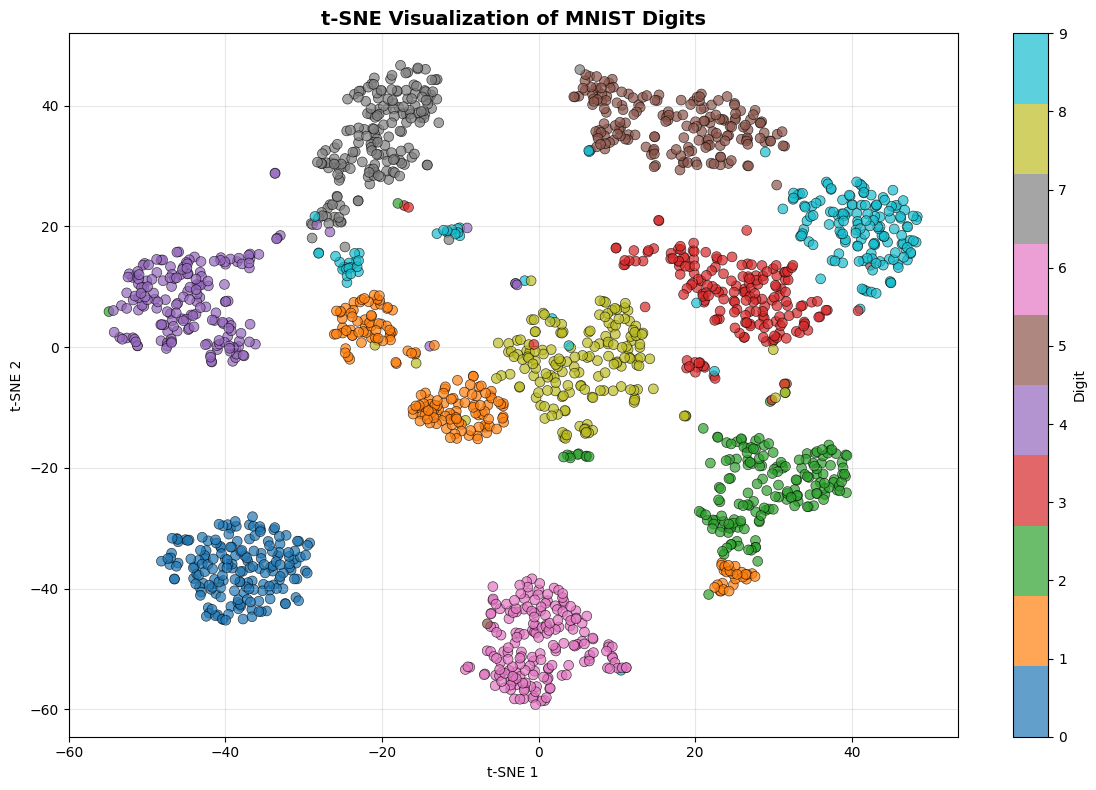


Observation: Digits form distinct clusters, showing that t-SNE preserves local structure well!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import time

# Load MNIST digits dataset (8x8 pixel images of digits 0-9)
digits = load_digits()
X = digits.data  # 1797 samples, 64 features
y = digits.target  # Labels 0-9

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# Standardize features (important for t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply t-SNE
print("\nApplying t-SNE (this may take a few seconds)...")
start_time = time.time()
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42,
    verbose=1
)
X_tsne = tsne.fit_transform(X_scaled)
elapsed = time.time() - start_time
print(f"Completed in {elapsed:.2f} seconds")

# Visualize
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=50, alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Digit')
plt.title('t-SNE Visualization of MNIST Digits', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservation: Digits form distinct clusters, showing that t-SNE preserves local structure well!")

## Practical Example 2: Impact of Perplexity

Computing t-SNE with perplexity=5...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Computing t-SNE with perplexity=30...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Computing t-SNE with perplexity=50...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


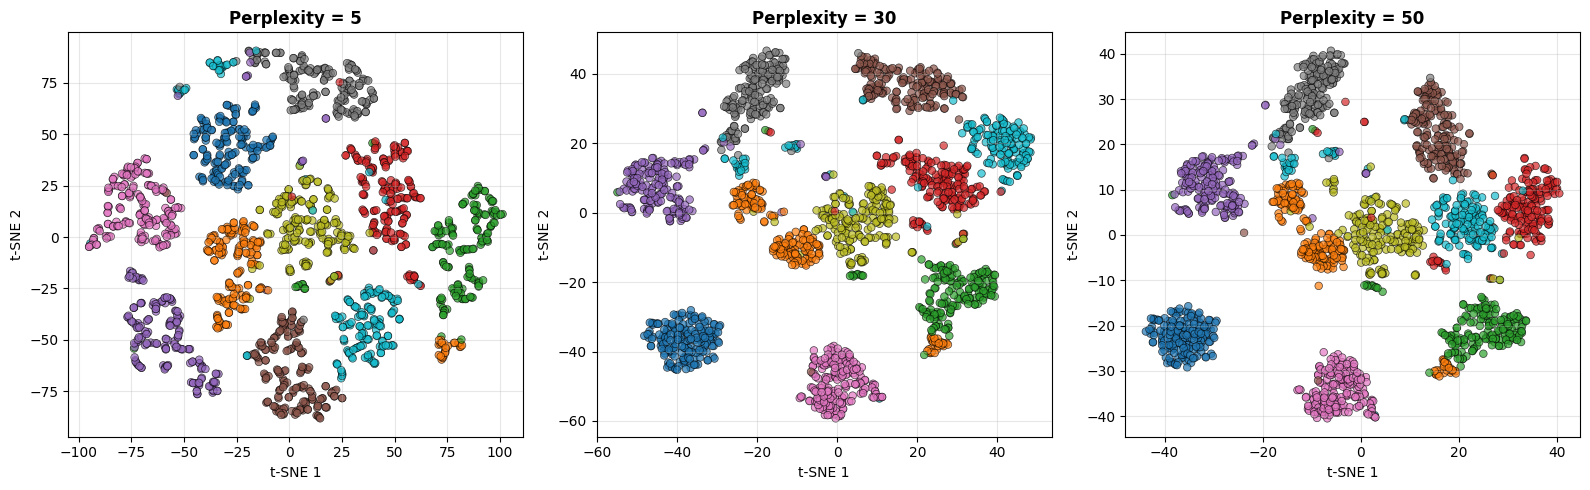


📊 Observations:
• Low perplexity (5): More fragmented, focuses on very local clusters
• Medium perplexity (30): Balanced, shows clear cluster structure
• High perplexity (50): Smoother, shows broader patterns


In [3]:
# Test different perplexity values
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, perp in enumerate(perplexities):
    print(f"Computing t-SNE with perplexity={perp}...")
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate=200,
        n_iter=1000,
        random_state=42
    )
    X_tsne_temp = tsne.fit_transform(X_scaled)
    
    scatter = axes[idx].scatter(X_tsne_temp[:, 0], X_tsne_temp[:, 1], 
                                c=y, cmap='tab10', s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
    axes[idx].set_title(f'Perplexity = {perp}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Observations:")
print("• Low perplexity (5): More fragmented, focuses on very local clusters")
print("• Medium perplexity (30): Balanced, shows clear cluster structure")
print("• High perplexity (50): Smoother, shows broader patterns")

## Practical Example 3: t-SNE vs PCA Comparison

Applying PCA...
PCA Explained Variance Ratio: [0.12033916 0.09561054]
Total Variance Explained: 21.59%


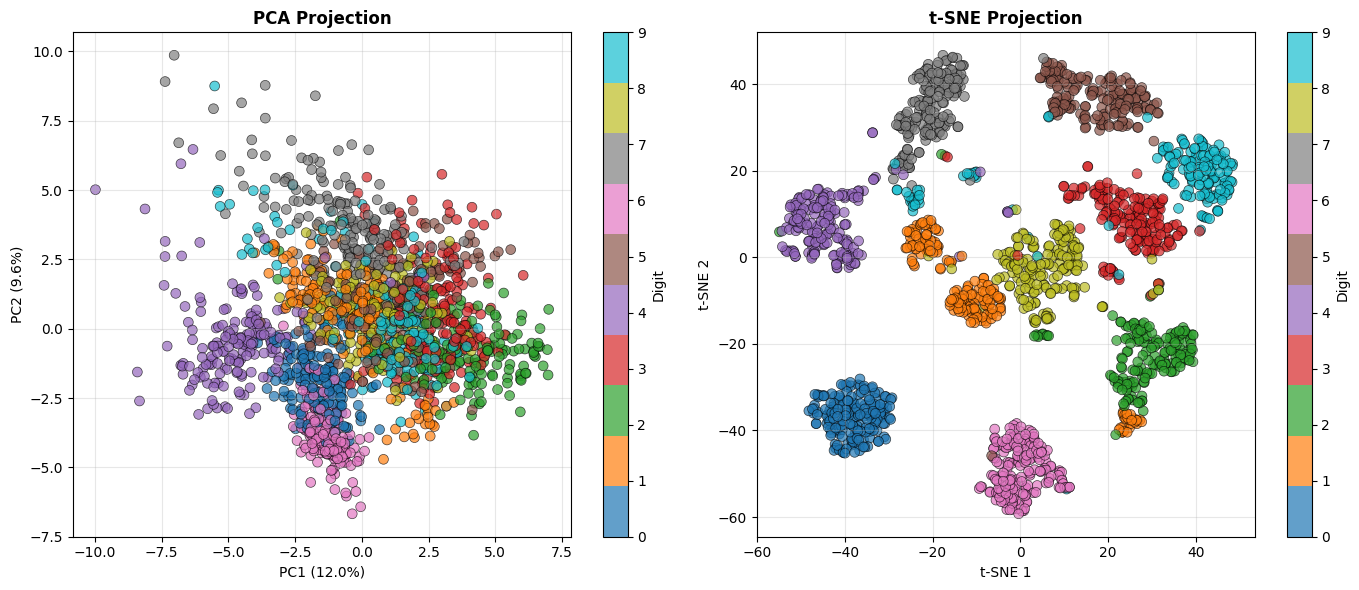


🔍 Key Differences:
PCA:
  ✓ Fast, interpretable (% variance explained)
  ✗ Preserves global structure, misses local clusters

t-SNE:
  ✓ Excellent for visualization, preserves local structure
  ✗ Slow, non-deterministic, hard to interpret results


In [4]:
from sklearn.decomposition import PCA

# Apply PCA for comparison
print("Applying PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

# Visualize both methods
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=50, alpha=0.7, edgecolors='k', linewidth=0.5)
axes[0].set_title('PCA Projection', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].grid(True, alpha=0.3)

# t-SNE
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=50, alpha=0.7, edgecolors='k', linewidth=0.5)
axes[1].set_title('t-SNE Projection', fontsize=12, fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True, alpha=0.3)

plt.colorbar(scatter1, ax=axes[0], label='Digit')
plt.colorbar(scatter2, ax=axes[1], label='Digit')
plt.tight_layout()
plt.show()

print("\n🔍 Key Differences:")
print("PCA:")
print("  ✓ Fast, interpretable (% variance explained)")
print("  ✗ Preserves global structure, misses local clusters")
print("\nt-SNE:")
print("  ✓ Excellent for visualization, preserves local structure")
print("  ✗ Slow, non-deterministic, hard to interpret results")

## Advantages vs Disadvantages

### ✅ Advantages
1. **Excellent Visualization**: Reveals structure invisible to linear methods
2. **Local Structure Preservation**: Keeps nearby points nearby
3. **Cluster Discovery**: Natural clustering becomes apparent
4. **Handles Non-Linear Relationships**: Works well with complex, curved manifolds
5. **Flexible**: Works with any distance metric

### ❌ Disadvantages
1. **Computational Cost**: $O(n^2)$ - slow for large datasets (>10k samples)
2. **Non-Deterministic**: Different runs give different results (unless fixed random_state)
3. **Not Parametrically Mappable**: Can't directly transform new data (need to recompute from scratch)
4. **Hard to Interpret**: No clear meaning to distances in output space
5. **Hyperparameter Sensitivity**: Results depend on perplexity, learning rate, n_iter
6. **Crowding Problem**: Can compress different clusters together in lower dimensions

## When to Use t-SNE

### ✅ Use t-SNE When:
- **Primary goal is visualization** (2D/3D plots)
- **Need to understand local cluster structure**
- **Dataset size is manageable** (< 100k samples)
- **Computational speed is not critical**
- **Exploring high-dimensional data** (images, text embeddings, etc.)

### ❌ Don't Use t-SNE When:
- **Need to transform new data** (not parametric)
- **Dataset is very large** (> 100k samples) → use approximations like ParametricTSNE
- **Need interpretable dimensions** → use PCA instead
- **Need reproducible results** → very non-deterministic
- **Working with very high dimensions** → use PCA for pre-processing first

## Real-World Applications

| Domain | Use Case |
|--------|----------|
| **Gene Expression** | Visualize cell types and clusters from RNA-seq data |
| **Computer Vision** | Explore learned CNN feature representations |
| **NLP** | Visualize word embeddings or document similarities |
| **Biology** | Analyze single-cell transcriptomics data |
| **Time Series** | Discover patterns in temporal sequences |
| **Anomaly Detection** | Identify outliers visually in high-dimensional data |

## Best Practices & Tips

### 1. Preprocessing
```python
# Always standardize/normalize features!
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

# Optional: Reduce dimensions with PCA first (for speed)
from sklearn.decomposition import PCA
X_reduced = PCA(n_components=50).fit_transform(X)
X_tsne = TSNE(n_components=2).fit_transform(X_reduced)
```

### 2. Parameter Selection
- **perplexity**: Start with 30, try 5-50 range
- **learning_rate**: Typically 200, range 10-1000
- **n_iter**: At least 1000, usually 1000-2000 is sufficient
- **n_components**: Use 2 or 3 for visualization

### 3. Reproducibility
```python
# Always set random_state for reproducible results
tsne = TSNE(random_state=42)
```

### 4. Large Datasets
```python
# Use PCA as pre-processing
X_pca = PCA(n_components=50, random_state=42).fit_transform(X)
# Then apply t-SNE
X_tsne = TSNE(n_components=2, n_iter=1000).fit_transform(X_pca)
```

### 5. Avoid Misinterpretation
⚠️ **Important**: 
- Distances in t-SNE output space are NOT interpretable
- Only the local neighborhood structure matters
- Absolute position and scale are meaningless
- Different runs can look very different - this is normal!

## Practical Example 4: Iris Dataset with Different Metrics

Computing t-SNE with metric=euclidean...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_5168/2318908806.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[idx].scatter([], [], c=plt.cm.viridis(i/3), s=100, label=target, edgecolors='black', linewidth=1)
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Computing t-SNE with metric=manhattan...


/tmp/ipykernel_5168/2318908806.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[idx].scatter([], [], c=plt.cm.viridis(i/3), s=100, label=target, edgecolors='black', linewidth=1)
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Computing t-SNE with metric=cosine...


/tmp/ipykernel_5168/2318908806.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[idx].scatter([], [], c=plt.cm.viridis(i/3), s=100, label=target, edgecolors='black', linewidth=1)


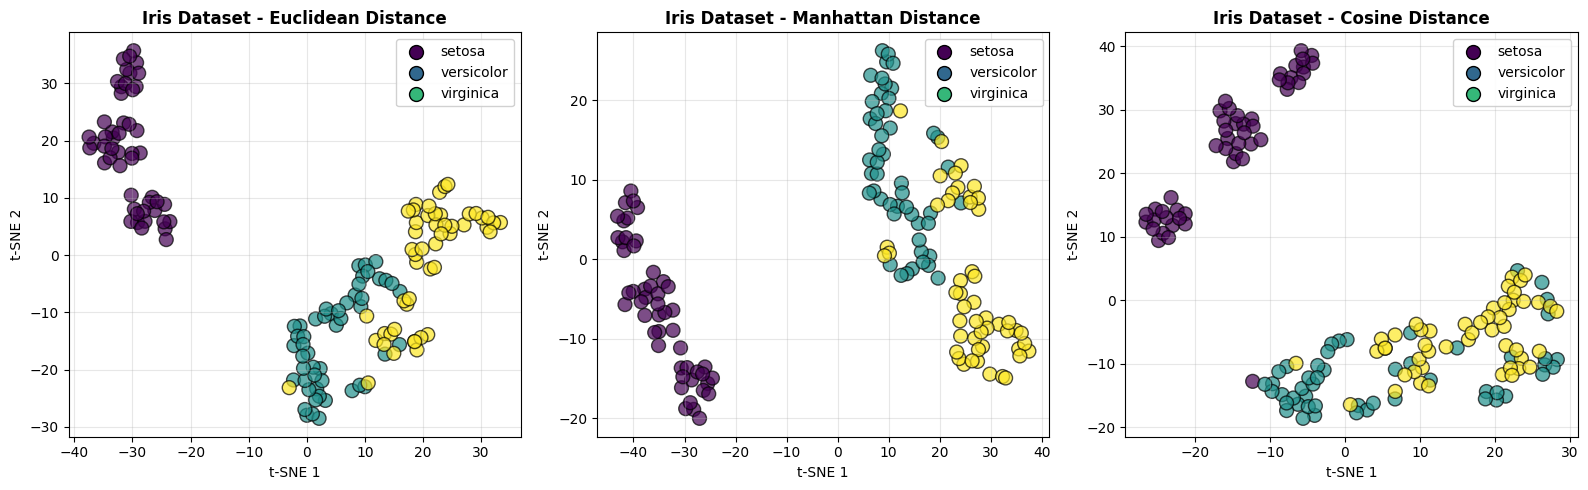


📊 Observations:
The choice of metric affects local structure but Iris clusters are well-separated in all cases


In [5]:
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names = iris.target_names

# Standardize
X_iris_scaled = StandardScaler().fit_transform(X_iris)

# Apply t-SNE with different distance metrics
metrics = ['euclidean', 'manhattan', 'cosine']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, metric in enumerate(metrics):
    print(f"Computing t-SNE with metric={metric}...")
    tsne = TSNE(
        n_components=2,
        perplexity=10,  # Small dataset, use lower perplexity
        metric=metric,
        random_state=42,
        n_iter=1000
    )
    X_iris_tsne = tsne.fit_transform(X_iris_scaled)
    
    scatter = axes[idx].scatter(X_iris_tsne[:, 0], X_iris_tsne[:, 1], 
                                c=y_iris, cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1)
    axes[idx].set_title(f'Iris Dataset - {metric.capitalize()} Distance', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].grid(True, alpha=0.3)
    
    # Add legend
    for i, target in enumerate(target_names):
        axes[idx].scatter([], [], c=plt.cm.viridis(i/3), s=100, label=target, edgecolors='black', linewidth=1)
    axes[idx].legend(loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()

print("\n📊 Observations:")
print("The choice of metric affects local structure but Iris clusters are well-separated in all cases")

## Comparison: t-SNE vs Other Dimensionality Reduction Methods

| Method | Speed | Local Structure | Interpretability | Use Case |
|--------|-------|-----------------|------------------|----------|
| **PCA** | ⚡ Very Fast | ❌ No | ✅ High (% variance) | Feature reduction, preprocessing |
| **t-SNE** | 🐢 Slow | ✅ Excellent | ❌ Low | Visualization, exploration |
| **UMAP** | ⚡ Faster than t-SNE | ✅ Good | ⚠️ Medium | Visualization, can handle large data |
| **Isomap** | ⚠️ Medium | ✅ Good | ⚠️ Medium | Non-linear structure |
| **Autoencoders** | ⚡ Fast (learned) | ✅ Depends | ⚠️ Medium | Feature extraction, transformation |
| **Kernel PCA** | ⚠️ Medium | ✅ Good | ⚠️ Medium | Non-linear dimensionality reduction |

### 🚀 Alternative: UMAP (Uniform Manifold Approximation and Projection)
- **Similar to t-SNE** but much faster
- **Preserves both local and global structure** better than t-SNE
- **Parametric**: Can transform new data
- Install: `pip install umap-learn`

## Practical Example 5: t-SNE vs UMAP Comparison

Applying t-SNE (this will take a few seconds)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Applying UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


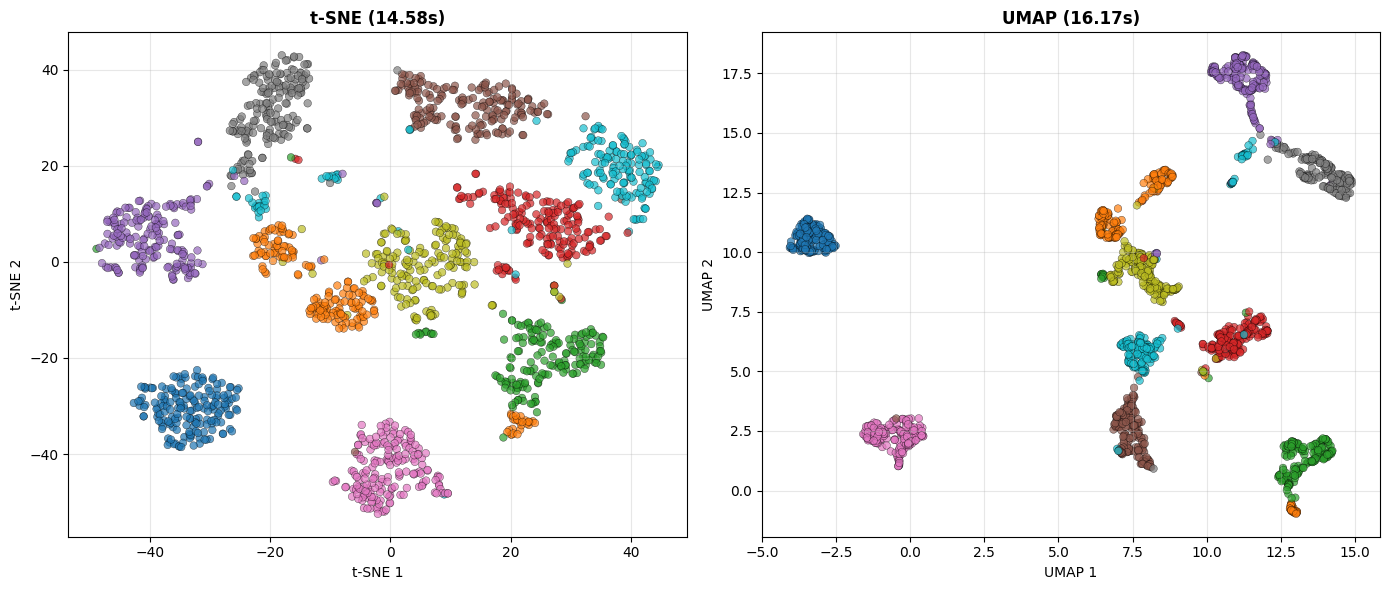


⏱️ Performance Comparison:
t-SNE time: 14.58s
UMAP time: 16.17s
UMAP is 0.9x faster

✨ Observations:
• Both preserve local structure well
• UMAP also preserves more global structure
• UMAP is significantly faster


In [6]:
# Compare t-SNE vs UMAP
try:
    import umap
    has_umap = True
except ImportError:
    has_umap = False
    print("⚠️ UMAP not installed. Install with: pip install umap-learn")

if has_umap:
    print("Applying t-SNE (this will take a few seconds)...")
    start_time = time.time()
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    X_tsne_digits = tsne.fit_transform(X_scaled)
    tsne_time = time.time() - start_time
    
    print(f"Applying UMAP...")
    start_time = time.time()
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    umap_time = time.time() - start_time
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    scatter1 = axes[0].scatter(X_tsne_digits[:, 0], X_tsne_digits[:, 1], c=y, cmap='tab10', s=30, alpha=0.7, edgecolors='k', linewidth=0.3)
    axes[0].set_title(f't-SNE ({tsne_time:.2f}s)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('t-SNE 1')
    axes[0].set_ylabel('t-SNE 2')
    axes[0].grid(True, alpha=0.3)
    
    scatter2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', s=30, alpha=0.7, edgecolors='k', linewidth=0.3)
    axes[1].set_title(f'UMAP ({umap_time:.2f}s)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n⏱️ Performance Comparison:")
    print(f"t-SNE time: {tsne_time:.2f}s")
    print(f"UMAP time: {umap_time:.2f}s")
    print(f"UMAP is {tsne_time/umap_time:.1f}x faster")
    print(f"\n✨ Observations:")
    print(f"• Both preserve local structure well")
    print(f"• UMAP also preserves more global structure")
    print(f"• UMAP is significantly faster")

## Common Pitfalls & Misunderstandings

### ❌ Mistake 1: Interpreting Distance
```
WRONG: "Point A and B are close, so they're similar"
RIGHT: "Point A and B are neighbors in the original space"
```
Distance in output space is NOT meaningful!

### ❌ Mistake 2: Using Raw Distances
```python
# WRONG - features have different scales
tsne = TSNE().fit_transform(X)

# RIGHT - always standardize first
X_scaled = StandardScaler().fit_transform(X)
tsne = TSNE().fit_transform(X_scaled)
```

### ❌ Mistake 3: Too Many Iterations
```python
# WRONG - runs forever and overfits
tsne = TSNE(n_iter=10000)

# RIGHT - 1000-2000 is usually enough
tsne = TSNE(n_iter=1000)
```

### ❌ Mistake 4: Using t-SNE for Feature Engineering
t-SNE output cannot be used as features for machine learning models (not parametric)
- Use PCA or Autoencoders for feature reduction before modeling
- Use t-SNE only for **visualization**

### ❌ Mistake 5: Large Datasets
```python
# WRONG - will be extremely slow
tsne = TSNE().fit_transform(X)  # 1M rows × 500 features

# RIGHT - reduce dimensions first
X_pca = PCA(n_components=50).fit_transform(X)
X_tsne = TSNE(n_components=2).fit_transform(X_pca)
```

## Key Takeaways 🎯

### What is t-SNE?
**Non-linear dimensionality reduction** that maps high-dimensional data to 2D/3D while **preserving local neighborhood structure**.

### How Does It Work?
1. Convert distances → probabilities (Gaussian kernel)
2. Initialize random 2D/3D projection
3. Use Student t-distribution to calculate similarities
4. Minimize KL-divergence between original and projected probability distributions

### Core Strengths
✅ Excellent for **visualization**  
✅ Discovers **local clustering patterns**  
✅ Works with **non-linear relationships**  
✅ Beautiful visualizations  

### Core Weaknesses
❌ **Slow** - not suitable for very large datasets  
❌ **Non-parametric** - can't transform new data  
❌ **Non-deterministic** - different runs give different results  
❌ **Hard to interpret** - distances are meaningless  

### When to Use
- **Visualization for exploration**: Use t-SNE ✅
- **Feature engineering for ML models**: Use PCA/Autoencoders ✅
- **Fast visualization**: Use UMAP ✅
- **Large datasets (>100k)**: Use UMAP or PCA ✅

### Mathematical Essence
$$\text{Minimize: } KL(P||Q) = \sum_i \sum_j p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

Where:
- $p_{ij}$ = similarity in high-dimensional space
- $q_{ij}$ = similarity in low-dimensional space

## Further Resources

### Original Paper
📄 **"Visualizing Data using t-SNE"** - van der Maaten & Hinton (2008)
- Introduces t-SNE algorithm
- Shows applications to different datasets

### Recommended Reading
📚 Distill.pub's interactive article on t-SNE  
📚 "How to Use t-SNE Effectively" - Wattenberg et al. (2016)  
📚 scikit-learn documentation on manifold learning  

### Related Techniques to Explore
- **UMAP** - Faster alternative, better global structure
- **Isomap** - Preserves geodesic distances
- **Autoencoders** - Learned, parametric non-linear reduction
- **PCA** - Linear baseline for comparison

### Implementation Libraries
```python
# scikit-learn (we used this)
from sklearn.manifold import TSNE

# UMAP (recommended for larger datasets)
from umap import UMAP

# TensorFlow/TensorBoard (built-in)
from tensorboard.plugins import projector
```

### Quick Reference: One-Liner
```python
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

X_tsne = TSNE(perplexity=30, random_state=42).fit_transform(
    StandardScaler().fit_transform(X)
)
```

---

### 🎓 Next Steps
1. **Experiment** with different perplexity values on your own data
2. **Compare** with PCA to understand the difference
3. **Try UMAP** as an alternative if t-SNE is too slow
4. **Use in EDA** to discover patterns before building models